# Кластеризация. Обучение без учителя

## Вопрос: Что такое обучение без учителя?

Кластеризация – это разбиение множества объектов на группы похожих, которые и называют кластерами.

**Постановка задачи:**

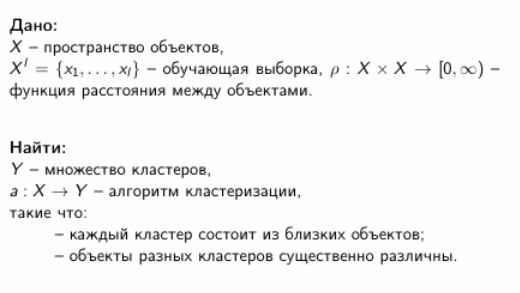

## Вопрос: Какие недостатки кластеризации вам известны?

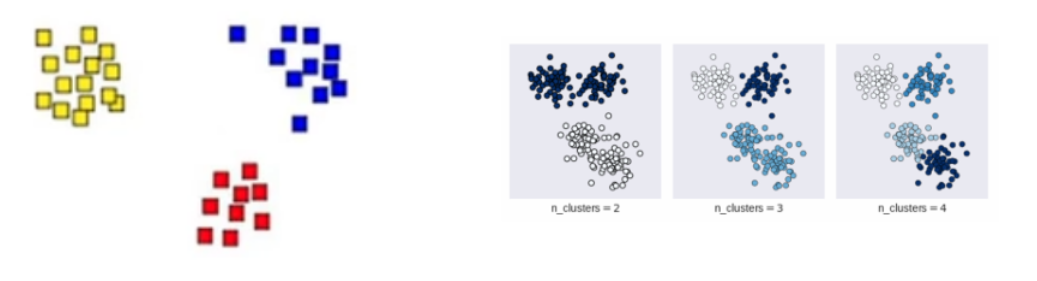

**Области применения кластеризации и её разновидности**

Кластеризация широко применяется в машинном обучении для решения различного спектра задач:

* классификация (определение к какому классу относится каждый объект или же выделение новых классов, которые не были известны заранее);

* сегментация рынка (разделение потенциальных клиентов на группы по их характеристикам для разработки более эффективных стратегий в маркетинге и продажах);

* сегментация изображений (разделение изображения на сегменты или группы пикселей);

* кластеризация геоданных (группировка данных по их географическому расположению, например, разделение районов на безопасные и опасные, богатые и бедные, и так далее);

* понижение размерности (уменьшение количества признаков путем объединения схожих в один кластер).

# Методы кластеризации

Наиболее популярные методы кластеризации в  Sklearn реализованы в классе Cluster

Существует множество различных типов кластеризации, которые можно разделить по следующим критериям:

**По способу формирования кластеров:**

* Разделительные (partitioning) — разбивают данные на заданное число кластеров, минимизируя расстояние внутри кластера и максимизируя расстояние между кластерами (например, K-means).

* Основанные на плотности (density-based) — группируют точки, которые находятся в областях с высокой плотностью и отделяют их от областей с низкой плотностью (например, DBSCAN).

* Основанные на сетке (grid-based) — разбивают пространство на ячейки сетки и анализируют плотность данных в каждой ячейке (например, STING).

* Основанные на модели (model-based) — предполагают, что данные порождены некоторой статистической моделью и пытаются подобрать параметры этой модели (например, смеси Гауссианов).

* Основанные на графах (graph-based) — используют графовое представление данных и разбивают его на подграфы, соответствующие кластерам (например, спектральная кластеризация).

* Основанные на подпространствах (subspace-based) — ищут кластеры в подпространствах признаков, а не во всём пространстве (например, CLIQUE).

* Основанные на ансамбле (ensemble-based) — комбинируют результаты различных алгоритмов кластеризации, чтобы получить более стабильное и надёжное разбиение (например, CSPA).

**По степени вложенности кластеров:**

* Плоские (flat) — разбивают данные на один уровень кластеров, не учитывая их иерархию (например, K-means).

* Иерархические (hierarchical) — разбивают данные на несколько уровней кластеров, учитывая их иерархию. Существуют два основных подхода к иерархической кластеризации: агломеративный (начинается с того, что каждый объект является отдельным кластером, а затем постепенно наиболее близкие кластеры объединяются в более крупные) и дивизивный (начинается с того, что все объекты составляют один кластер, а затем постепенно разделяются на более мелкие кластеры).

**По степени пересечения кластеров:**

* Четкие (Исключающие) (exclusive) — каждый объект принадлежит только одному кластеру (например, K-means).

* Перекрывающие (overlapping) — каждый объект может принадлежать нескольким кластерам (например, MCOKE).

* Нечёткие (fuzzy) — каждый объект принадлежит каждому кластеру с некоторой степенью принадлежности (например, fuzzy K-means).



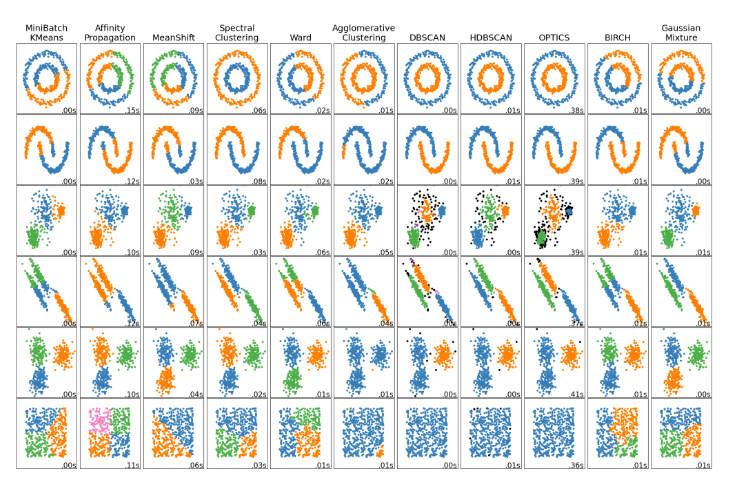

**Как это работает в коде?**

In [ ]:
from sklearn.cluster import KMeans
import numpy as np

X = np.array([[1, 2], [1, 4], [1, 0],
              [10, 2], [10, 4], [10, 0]])

kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto")

kmeans.fit(X)
kmeans.labels_
kmeans.predict([[0, 0], [12, 3]])
kmeans.cluster_centers_

array([[10.,  2.],
       [ 1.,  2.]])

# K-Means

На лекции вы успели познакомиться с методом k-средних. Он ищет k скрытых кластеров, каждый из которых характеризуется центроидом или средним.

Алгоритм находит эти кластеры с помощью итеративной процедуры, которая минимизирует следующую целевую функцию.

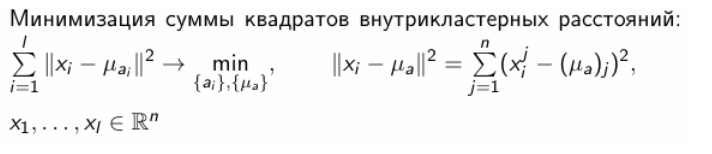

Понятно, что здравый смысл в этом есть: мы хотим, чтобы точки располагались кучно возле центров своих кластеров. Но вот незадача: минимум такого функционала будет достигаться тогда, когда кластеров столько же, сколько и точек (то есть каждая точка – это кластер из одного элемента).

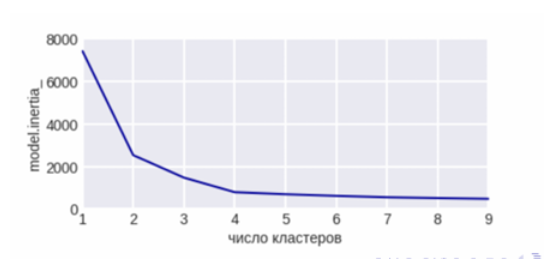

Для решения этого вопроса (выбора числа кластеров) часто пользуются такой эвристикой: выбирают то число кластеров, начиная с которого целевая функция падает "уже не так быстро". Здесь это в районе 3.

Второй способ выбора числа кластеров - это выбрать то k, при котором значение метрики силуэта максимально.

**Псевдокод:**

1. Выбрать количество кластеров $k$, которое нам кажется оптимальным для наших данных.
2. Выбрать случайным образом в пространстве наших данных $k$ точек (центроидов).
3. Для каждой точки посчитать, к какому центроиду она ближе.
4. Переместить каждый центроид в центр выборки, которую мы отнесли к этому центроиду.
5. Повторять последние два шага фиксированное число раз, либо до тех пор пока центроиды не "сойдутся" (обычно это значит, что их смещение относительно предыдущего положения не превышает какого-то заранее заданного небольшого значения).

**Сложность алгоритма:**

Само по себе решение задачи K-means NP-трудное (NP-hard), и для размерности $d$, числа кластеров $k$ и числа точек $n$ решается за $O(n^{d k+1})$. Для решения такой боли часто используются эвристики, например MiniBatch K-means, который для обучения использует не весь датасет целиком, а лишь маленькие его порции (batch) и обновляет центроиды используя среднее за всю историю обновлений центроида от всех относящихся к нему точек.

И поскольку нам требуется разбить множество точек на K кластеров так, чтобы минимизировать сумму квадратов расстояний от точек до центров кластеров, то само по себе решение будет NP-трудным. Для оптимизации алгоритма, то есть для повышения скорости работы на больших данных, мы можем использовать не всю выборку, а ее часть. С другой стороны, хотя MiniBatch работает быстрее, он дает опять же менее стабильные результаты и требует более тонкой настройки.

**Преимущества и недостатки K-Means**

Преимущества:

* прост в реализации и понимании;

* наличие большого числа модификаций;

* высокая скорость работы и точность на данных сферической формы.

Недостатки:

* низкая точность на данных с несферической формой кластеров;

* чувствительность к начальным значениям центроидов и выбросам;

* необходимость заранее устанавливать число кластеров, что может быть сложно или не оптимально.

Пример визуализации алгоритма: https://www.naftaliharris.com/blog/visualizing-k-means-clustering/

## Задание реализовать алгоритм k-means по псевдокоду

In [ ]:
from scipy.spatial.distance import cdist
import numpy as np

class KMeans_history:
    def __init__(self, n_clusters=3, max_iter=10, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.cent_history = []
        self.centroids_ = None
        
    def fit(self, X):
        """
        Применяет алгоритм K-means к данным X.
        Возвращает историю центроидов на каждой итерации.
        """
        # Устанавливаем seed для воспроизводимости
        np.random.seed(seed=self.random_state)
        
        # Инициализируем центроиды случайным образом
        centroids = np.random.normal(loc=0.0, scale=1., size=self.n_clusters*X.shape[1])
        centroids = centroids.reshape((self.n_clusters, X.shape[1]))
        
        # Очищаем историю и добавляем начальные центроиды
        self.cent_history = [centroids.copy()]
        
        for i in range(self.max_iter):
            # TODO
            # Считаем расстояния от наблюдений до центроид

            # Смотрим, до какой центроиды каждой точке ближе всего
            
            # Обновляем центроиды
            
            # Добавляем новые центроиды в историю
            
            # Проверяем, изменились ли центроиды (ранняя остановка)
        
        self.centroids_ = centroids
        return self.cent_history
    
    def predict(self, X):
        """
        Предсказывает кластеры для новых данных X
        на основе последних центроидов.
        """
        if self.centroids_ is None:
            raise ValueError("Модель не обучена. Сначала вызовите fit().")
        
        distances = cdist(X, self.centroids_)
        labels = distances.argmin(axis=1)
        return labels


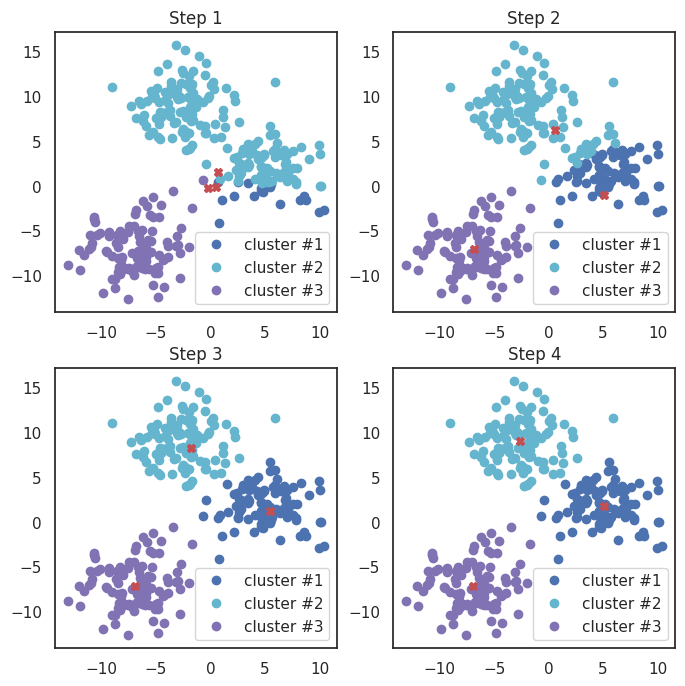

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Создаем данные
X, y_true = make_blobs(n_samples=300, centers=3, n_features=2,
                        cluster_std=2.5, random_state=42)

# Создаем и обучаем модель
kmeans = KMeans_history(n_clusters=3, max_iter=4, random_state=30)
cent_history = kmeans.fit(X)

# Делаем предсказания
y_pred = kmeans.predict(X)

# Визуализируем результат
plt.figure(figsize=(8, 8))
for i in range(4):
    distances = cdist(X, cent_history[i])
    labels = distances.argmin(axis=1)

    plt.subplot(2, 2, i + 1)
    plt.plot(X[labels == 0, 0], X[labels == 0, 1], 'bo', label='cluster #1')
    plt.plot(X[labels == 1, 0], X[labels == 1, 1], 'co', label='cluster #2')
    plt.plot(X[labels == 2, 0], X[labels == 2, 1], 'mo', label='cluster #3')
    plt.plot(cent_history[i][:, 0], cent_history[i][:, 1], 'rX')
    plt.legend(loc=0)
    plt.title('Step {:}'.format(i + 1));

plt.tight_layout()
plt.show()

print(f"Количество итераций: {len(cent_history) - 1}")
print(f"Финальные центроиды:\n{kmeans.centroids_}")

# Оценка качества кластеризации

## Silhouette score: суть и математическая основа метрики

Silhouette score — это метрика качества кластеризации, которая измеряет, насколько похож объект на объекты своего кластера по сравнению с объектами других кластеров. Значения варьируются от -1 до 1, где более высокие значения указывают на лучшее разделение кластеров.

Математически Silhouette score для отдельного объекта i определяется как:

$$s(i) = (b(i) – a(i)) / max(a(i), b(i))$$

Где:

* a(i) — среднее расстояние от объекта i до всех других объектов в том же кластере (внутрикластерное расстояние)

* b(i) — минимальное среднее расстояние от объекта i до объектов в любом другом кластере (межкластерное расстояние)

Общий Silhouette score для модели — это среднее значение всех s(i) для каждого объекта в наборе данных.

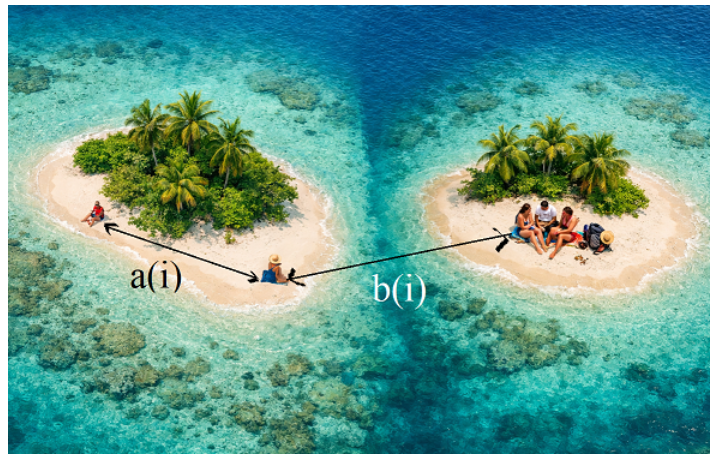

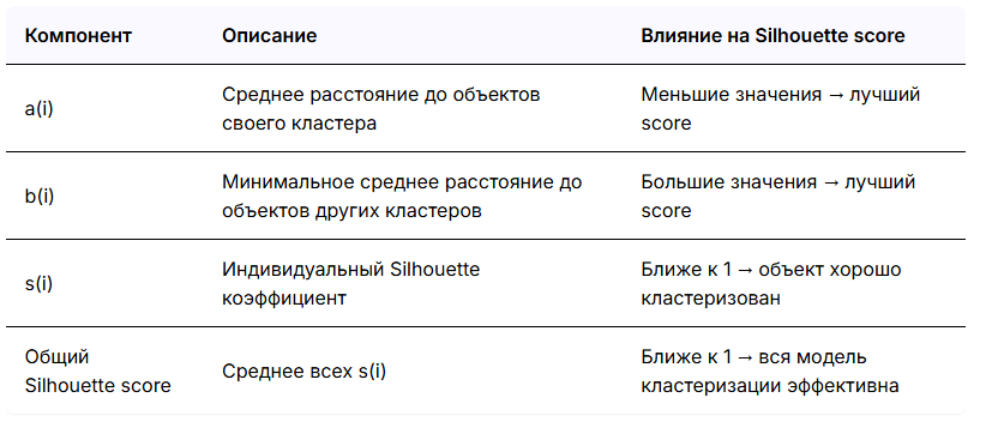

## Силуэт кластера (Cluster silhouette)

Силуэт кластера — метод графического представления результатов кластеризации, с помощью которого можно визуально оценить качество построенной кластерной модели.

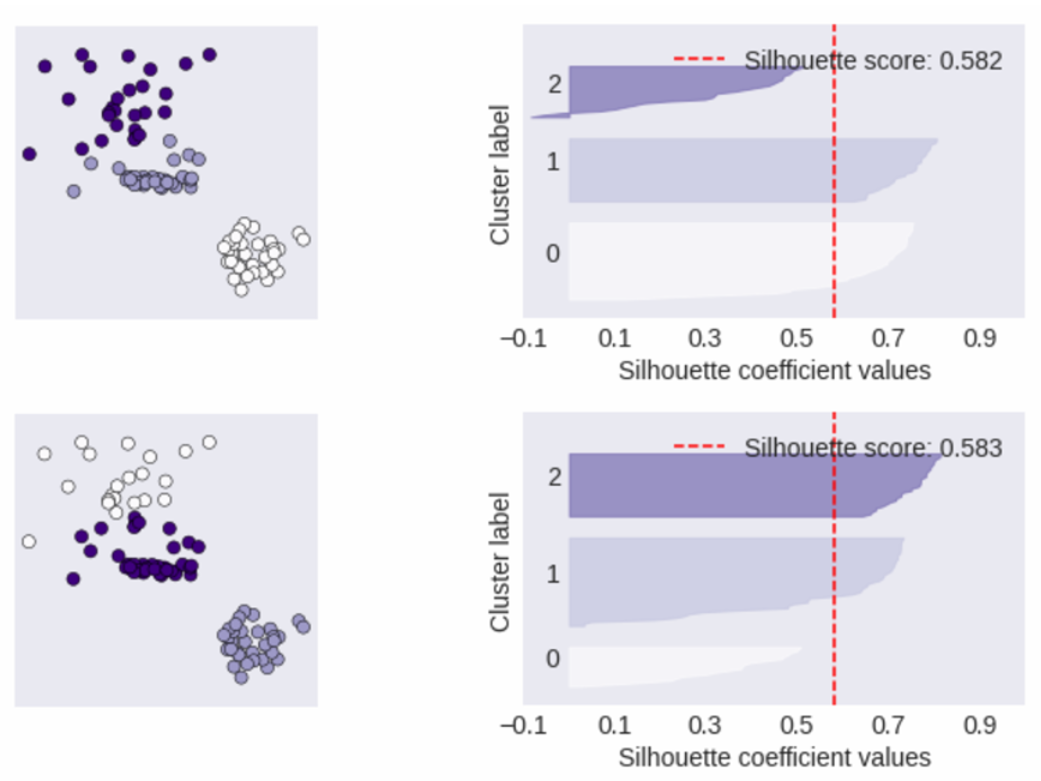

**По форме силуэтов можно быстро оценить качество кластеризации. Чем форма силуэтов ближе к прямоугольной, а площадь (средний коэффициент силуэта) ближе к 1, тем лучше кластеризация.**

**Чем больше в кластере объектов с низким коэффициентом силуэта, которые порождают «узкие» силуэты, тем хуже кластеризация.**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

def plot_clustering_and_silhouette_with_negatives(kmeans, X, labels, n_clusters, title="Анализ силуэта кластеров"):
    """
    Функция для визуализации с выделением точек с отрицательным силуэтом
    """
    # Создаем фигуру с тремя подграфиками
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    # Получаем значения силуэта для каждого образца
    silhouette_vals = silhouette_samples(X, labels)
    silhouette_avg = silhouette_score(X, labels)
    cluster_silhouette_avg = []

    # Находим точки с отрицательным силуэтом
    negative_mask = silhouette_vals < 0
    n_negative = np.sum(negative_mask)

    # 1. График силуэта кластеров
    y_lower = 10
    colors_clusters = []

    for i in range(n_clusters):
        # Получаем значения силуэта для текущего кластера
        cluster_indices = np.where(labels == i)[0]
        cluster_silhouette_vals = silhouette_vals[cluster_indices]
        cluster_silhouette_avg.append(cluster_silhouette_vals.mean())

        # Сортируем для красивой визуализации
        sorted_indices = cluster_indices[np.argsort(cluster_silhouette_vals)]
        cluster_silhouette_vals = np.sort(cluster_silhouette_vals)

        size_cluster = len(cluster_silhouette_vals)
        y_upper = y_lower + size_cluster

        # Определяем цвет для кластера
        color = cm.nipy_spectral(float(i) / n_clusters)
        colors_clusters.append(color)

        # Раскрашиваем положительные и отрицательные значения по-разному
        positive_vals = cluster_silhouette_vals[cluster_silhouette_vals >= 0]
        negative_vals = cluster_silhouette_vals[cluster_silhouette_vals < 0]

        # Рисуем положительные значения
        if len(positive_vals) > 0:
            pos_y_start = y_lower + len(negative_vals)
            ax1.fill_betweenx(np.arange(pos_y_start, y_lower + size_cluster),
                             0, positive_vals, facecolor=color, alpha=0.7)

        # Рисуем отрицательные значения красным
        if len(negative_vals) > 0:
            ax1.fill_betweenx(np.arange(y_lower, y_lower + len(negative_vals)),
                             negative_vals, 0, facecolor='red', alpha=0.7)
            # Добавляем красную границу
            ax1.axhline(y=y_lower + len(negative_vals), color='red', linestyle='-', linewidth=0.5)

        # Добавляем метку кластера
        ax1.text(-0.1, y_lower + 0.5 * size_cluster, f'Кластер {i}',
                fontsize=10, fontweight='bold')

        y_lower = y_upper + 10

    # Оформляем график силуэта
    ax1.set_title(f"График силуэта (красным - отрицательные значения)\nВсего точек с отр. силуэтом: {n_negative}")
    ax1.set_xlabel("Значение силуэта")
    ax1.set_ylabel("Кластеры")
    ax1.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax1.axvline(x=silhouette_avg, color="green", linestyle="--",
                label=f"Средний: {silhouette_avg:.3f}")
    ax1.legend()
    ax1.set_yticks([])
    ax1.set_xlim([-0.3, 1])
    ax1.grid(True, alpha=0.3, axis='x')

    # 2. График кластеризации с выделением проблемных точек
    colors = [colors_clusters[label] for label in labels]

    # Нормальные точки
    ax2.scatter(X[~negative_mask, 0], X[~negative_mask, 1],
                c=[colors[i] for i in np.where(~negative_mask)[0]],
                s=50, alpha=0.6, edgecolors='black', linewidth=0.5, label='Нормальные точки')

    # Точки с отрицательным силуэтом (выделяем красным)
    if n_negative > 0:
        ax2.scatter(X[negative_mask, 0], X[negative_mask, 1],
                   c='red', s=100, alpha=0.8, edgecolors='darkred',
                   linewidth=2, label=f'Точки с отр. силуэтом ({n_negative})', zorder=5)

    ax2.set_title("Кластеры с выделением проблемных точек")
    ax2.set_xlabel("Признак 1")
    ax2.set_ylabel("Признак 2")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Отдельный график только для проблемных точек
    if n_negative > 0:
        # Раскрашиваем проблемные точки по их кластерам
        negative_labels = labels[negative_mask]
        negative_colors = [colors_clusters[label] for label in negative_labels]

        ax3.scatter(X[negative_mask, 0], X[negative_mask, 1],
                   c=negative_colors, s=100, alpha=0.8, edgecolors='red', linewidth=2)

        # Добавляем стрелки к центрам кластеров (для K-means)
        if hasattr(kmeans, 'cluster_centers_'):
            centers = kmeans.cluster_centers_
            ax3.scatter(centers[:, 0], centers[:, 1], marker='X',
                       c='green', s=200, linewidths=3, label='Центры кластеров')

            # Для каждой проблемной точки показываем, к какому центру она принадлежит
            for idx in np.where(negative_mask)[0]:
                point = X[idx]
                cluster = labels[idx]
                center = centers[cluster]
                ax3.annotate('', xy=center, xytext=point,
                            arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5, lw=1))

        ax3.set_title(f"Точки с отрицательным силуэтом\n(цвет - их кластер, обведены красным)")
        ax3.set_xlabel("Признак 1")
        ax3.set_ylabel("Признак 2")
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        # 4. Гистограмма значений силуэта
        ax4.hist(silhouette_vals, bins=30, edgecolor='black', alpha=0.7)
        ax4.axvline(x=0, color='red', linestyle='--', linewidth=2, label='0 (граница)')
        ax4.axvline(x=silhouette_avg, color='green', linestyle='--', linewidth=2,
                   label=f'Среднее: {silhouette_avg:.3f}')
        ax4.set_xlabel('Значение силуэта')
        ax4.set_ylabel('Количество точек')
        ax4.set_title('Распределение значений силуэта')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
    else:
        ax3.text(0.5, 0.5, 'Нет точек с отрицательным силуэтом!',
                ha='center', va='center', transform=ax3.transAxes, fontsize=14)
        ax3.set_title('Точки с отрицательным силуэтом')
        ax4.remove()

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    return fig, silhouette_avg, cluster_silhouette_avg

In [ ]:
# Пример 1: Плохо разделенные кластеры (blobs)

np.random.seed(7)
x1 = np.random.normal(3, 1, (50, 2))  # Cluster 1 centered at 3
x2 = np.random.normal(9, 1, (100, 2))  # Cluster 2 centered at 9
x3 = np.random.normal(10, 3, (100, 2)) # Cluster 3 centered at 10

data = np.vstack((x1, x2, x3))

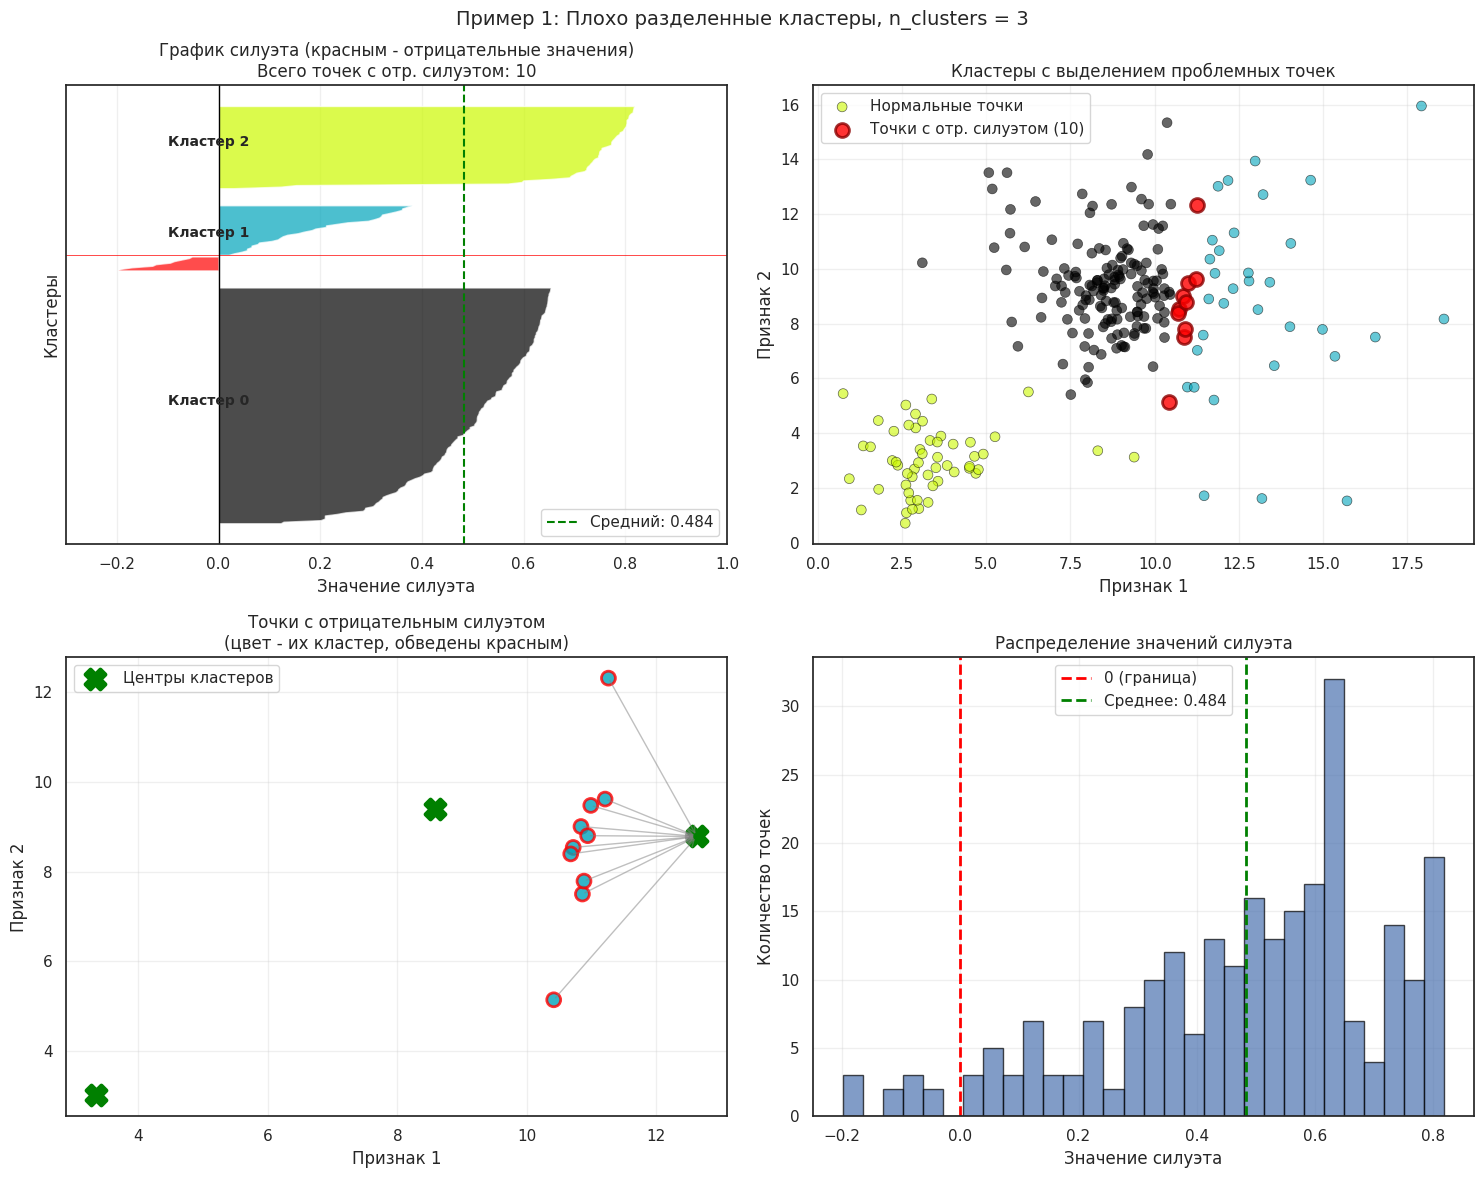

Средний коэффициент силуэта: 0.484:,  [np.float64(0.5022064786785599), np.float64(0.12178923472128306), np.float64(0.7186572324792644)]
Интерпретация: Значение близко к 1 -> кластеры хорошо сгруппированы и разделены.

Интерпретация: Есть отрицательные значения силуэта -> вероятно, точка назначена неправильному кластеру.

Интерпретация: Оценка, близкая к 0 -> означает, что точки находятся на границах принятия решения между двумя кластерами или очень близки к ним. Это указывает на то, что кластеризация нечетко определена и может быть неоднозначной.



In [ ]:
# Применяем K-means
kmeans = KMeans(n_clusters=3, random_state=42)
labels_blobs = kmeans.fit_predict(data)

# Визуализируем
fig1, score1, scores = plot_clustering_and_silhouette_with_negatives(kmeans, data, labels_blobs, 3,
                       "Пример 1: Плохо разделенные кластеры, n_clusters = 3")
plt.show()

print(f"Средний коэффициент силуэта: {score1:.3f}:, ", scores)
print("Интерпретация: Значение близко к 1 -> кластеры хорошо сгруппированы и разделены.\n")
print("Интерпретация: Есть отрицательные значения силуэта -> вероятно, точка назначена неправильному кластеру.\n")
print("Интерпретация: Оценка, близкая к 0 -> означает, что точки находятся на границах принятия решения между двумя кластерами или очень близки к ним. Это указывает на то, что кластеризация нечетко определена и может быть неоднозначной.\n")

In [ ]:
# Применяем K-means
kmeans = KMeans(n_clusters=2, random_state=42)
labels_blobs = kmeans.fit_predict(data)

# Визуализируем
fig1, score1, scores = plot_clustering_and_silhouette_with_negatives(kmeans, data, labels_blobs, 3,
                       "Пример 1: Плохо разделенные кластеры, n_clusters = 2")
plt.show()

print(f"Средний коэффициент силуэта: {score1:.3f}:, ", scores)

ПРИМЕР 2: Четко разделенные кластеры (blobs)


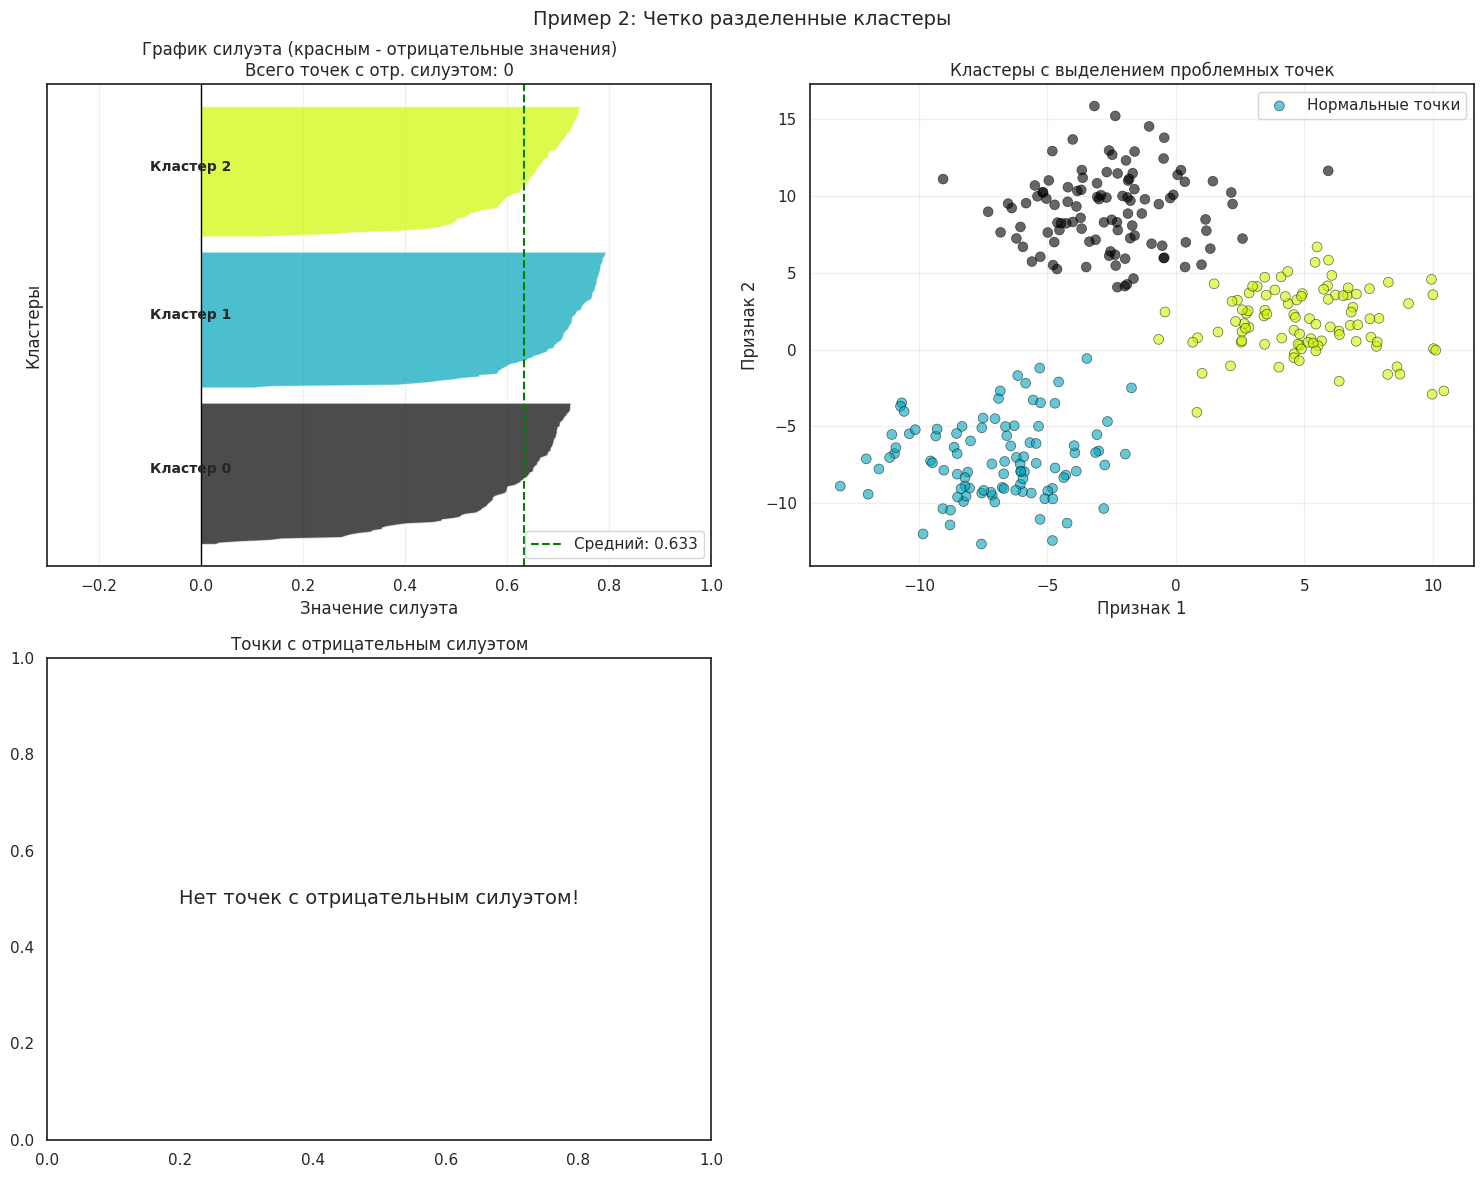

Средний коэффициент силуэта: 0.633:,  [np.float64(0.5825564702306372), np.float64(0.6927697509446462), np.float64(0.6244029772719363)]


In [ ]:
# Пример 2: Четко разделенные кластеры (blobs)
print("=" * 60)
print("ПРИМЕР 2: Четко разделенные кластеры (blobs)")
print("=" * 60)

# Генерируем данные
X_blobs, y_true = make_blobs(n_samples=300, centers=3, n_features=2,
                             cluster_std=2.5, random_state=42)

# Применяем K-means
kmeans = KMeans(n_clusters=3, random_state=42)
labels_blobs = kmeans.fit_predict(X_blobs)

# Визуализируем
fig1, score1, scores = plot_clustering_and_silhouette_with_negatives(kmeans, X_blobs, labels_blobs, 3,
                                              "Пример 2: Четко разделенные кластеры")
plt.show()

print(f"Средний коэффициент силуэта: {score1:.3f}:, ", scores)

### Ограничения и альтернативы Silhouette score

**Основные ограничения Silhouette score:**

* Чувствительность к форме кластеров: Метрика лучше работает с компактными, выпуклыми кластерами. При наличии кластеров сложной формы (например, концентрических окружностей) Silhouette score может давать некорректные результаты.

* Вычислительная сложность: Для больших наборов данных вычисление O(n²) может стать критическим ограничением.

* Предположение об эвклидовом расстоянии: По умолчанию метрика использует эвклидово расстояние, что не всегда оптимально для высокоразмерных или категориальных данных.

* Проблемы с несбалансированными кластерами: При значительной разнице в размерах кластеров Silhouette score может отдавать предпочтение решениям с более равномерным распределением.

* Сложности с шумовыми точками: Алгоритмы типа DBSCAN, которые классифицируют некоторые точки как шум, требуют специальной обработки при вычислении Silhouette score.

Учитывая эти ограничения, имеет смысл рассмотреть альтернативные метрики оценки качества кластеризации. На рисунке представлена таблица сравнения Silhouette score с альтернативными метриками по ключевым характеристикам:


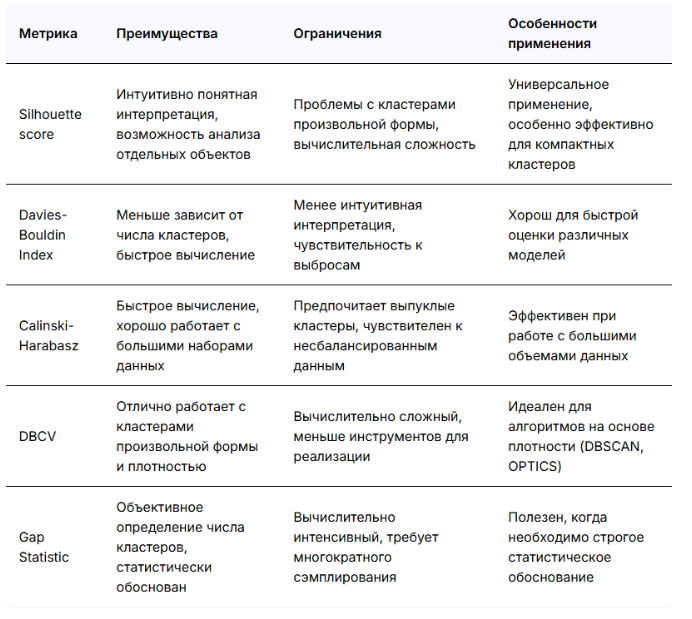

При выборе метрики для оценки кластеризации рекомендуется:

* Учитывать специфику данных и ожидаемую форму кластеров.

* Использовать несколько метрик для более полной картины.

* Применять визуализацию результатов для интуитивной проверки.

* Оценивать общий смысл полученных кластеров, а не только статистические показатели.


**Важно помнить, что ни одна метрика не является универсальным решением. Комбинация методов, учитывающая специфику конкретной задачи, обычно даёт наиболее надежные результаты.**

Статья на тему метрик для задачи кластеризции: https://habr.com/ru/companies/yandex/articles/500742/?ysclid=mmaldoucn6720049869

# Использование кластеризации

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis, LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Генерируем данные в форме двух лун
X_moons, y_moons = make_moons(n_samples=300, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_moons, y_moons, test_size=0.3, random_state=42)

gnb = GaussianNB()
gnb.fit(X_train, y_train)
print('gnb:', accuracy_score(y_test, gnb.predict(X_test)))

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
print('lda:', accuracy_score(y_test, lda.predict(X_test)))

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
print('qda:', accuracy_score(y_test, qda.predict(X_test)))

gnb: 0.9
lda: 0.9
qda: 0.9


In [ ]:
# 1. ПРОСТОЕ ДОБАВЛЕНИЕ МЕТКИ КЛАСТЕРА
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels_train = kmeans.fit_predict(X_train)
cluster_labels_test = kmeans.predict(X_test)

# Добавляем метку кластера как новый признак
X_train_with_cluster = np.column_stack([X_train, cluster_labels_train])
X_test_with_cluster = np.column_stack([X_test, cluster_labels_test])

print("=== С МЕТКОЙ КЛАСТЕРА ===")
gnb = GaussianNB()
gnb.fit(X_train_with_cluster, y_train)
print('gnb:', accuracy_score(y_test, gnb.predict(X_test_with_cluster)))

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_with_cluster, y_train)
print('lda:', accuracy_score(y_test, lda.predict(X_test_with_cluster)))

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_with_cluster, y_train)
print('qda:', accuracy_score(y_test, qda.predict(X_test_with_cluster)))



=== С МЕТКОЙ КЛАСТЕРА ===
gnb: 0.9
lda: 0.9555555555555556
qda: 0.9444444444444444


In [ ]:
# 2. РАССТОЯНИЯ ДО ЦЕНТРОВ КЛАСТЕРОВ
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train)

# Вычисляем расстояния до центров кластеров
distances_train = kmeans.transform(X_train)  # Расстояния до каждого центра
distances_test = kmeans.transform(X_test)  # Расстояния до каждого центра

# Добавляем расстояния как новые признаки
X_train_with_distances = np.column_stack([X_train, distances_train])
X_test_with_distances = np.column_stack([X_test, distances_test])

print("\n=== С РАССТОЯНИЯМИ ДО ЦЕНТРОВ ===")
gnb = GaussianNB()
gnb.fit(X_train_with_distances, y_train)
print('gnb:', accuracy_score(y_test, gnb.predict(X_test_with_distances)))

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_with_distances, y_train)
print('lda:', accuracy_score(y_test, lda.predict(X_test_with_distances)))

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_with_distances, y_train)
print('qda:', accuracy_score(y_test, qda.predict(X_test_with_distances)))


=== С РАССТОЯНИЯМИ ДО ЦЕНТРОВ ===
gnb: 0.8888888888888888
lda: 1.0
qda: 1.0


In [15]:
from sklearn.datasets import make_blobs
import numpy as np

# Создаем сетку 4x4x4 (64 класса)
def create_grid_dataset(n_samples_per_class=100, grid_size=4):
    """
    Создает набор данных в виде сетки grid_size x grid_size
    Каждая ячейка сетки - отдельный класс
    """
    n_classes = grid_size * grid_size * grid_size
    X_list = []
    y_list = []

    # Создаем точки для каждой ячейки сетки
    for i in range(grid_size):
        for j in range(grid_size):
            for k in range(grid_size):
                # Центр текущей ячейки
                center_x = i * 2  # Расстояние между центрами по x
                center_y = j * 4  # Расстояние между центрами по y
                center_z = k * 6  # Расстояние между центрами по z

                # Генерируем точки вокруг центра с небольшим разбросом
                X_class, _ = make_blobs(n_samples=n_samples_per_class,
                                    n_features=3,
                                    centers=[[center_x, center_y, center_z]],
                                    cluster_std=0.3,
                                    random_state=42 + i*grid_size + j + k*2)

                X_list.append(X_class)
                y_list.append(np.full(n_samples_per_class, i*grid_size*3//2 + j + k*9//11))

    X = np.vstack(X_list)
    y = np.hstack(y_list)

    return X, y

# Generate synthetic data
X, y = create_grid_dataset(n_samples_per_class=100, grid_size=4)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)


In [16]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

print(accuracy_score(y_test, gnb.predict(X_test)))
print(accuracy_score(y_test, lda.predict(X_test)))
print(accuracy_score(y_test, knn.predict(X_test)))

0.7365625
0.9809375
0.9971875


In [17]:
# 3. КЛАСТЕРИЗАЦИЯ ДЛЯ СОКРАЩЕНИЯ ОБЪЕМА ДАННЫХ

# Берем последние два признака для кластеризации (индексы 1 и 2)
X_clustering_train = X_train[:, 1:3]  # Второй и третий признаки
X_clustering_test = X_test[:, 1:3]  # Второй и третий признаки

# Применяем KMeans для создания кластерных меток
# Выбираем количество кластеров (можно оптимизировать)
n_clusters = 16  # Меньше чем исходных классов, но достаточно для структуры

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels_train = kmeans.fit_predict(X_clustering_train)
cluster_labels_test = kmeans.predict(X_clustering_test)

# Создаем новые признаки: первый столбец + метка кластера
X_with_clusters_train = np.column_stack([X_train[:, 0], cluster_labels_train])
X_with_clusters_test = np.column_stack([X_test[:, 0], cluster_labels_test])


gnb = GaussianNB()
gnb.fit(X_with_clusters_train, y_train)

lda = LinearDiscriminantAnalysis()
lda.fit(X_with_clusters_train, y_train)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_with_clusters_train, y_train)

print(accuracy_score(y_test, gnb.predict(X_with_clusters_test)))
print(accuracy_score(y_test, lda.predict(X_with_clusters_test)))
print(accuracy_score(y_test, knn.predict(X_with_clusters_test)))

0.62875
0.3815625
0.998125


**Можно также попробовать сначала добавить столбцы с кластеризацией, а потом применить lda для сокращения данных.**

# Сегментация изображений

### Задание: Сегментировать изображение с помощью метода K-Means.

1. Обучите модель K-means. 
2. Выведите график плеча и подберите оптимальное k.
3. Выведите на экран: исходное изображение, сегментированное изображение, гистограмму с центроидами.

In [19]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

# Загружаем изображение
img = cv2.imread('blur_43_20.png')
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
X = gray_img.reshape(-1, 1)

# Метод локтя для определения оптимального k
def get_inertias_by_KMeans(X, start=2, end=10):
    inertias = []
    # TODO
    return inertias

inertias = get_inertias_by_KMeans(X, start=2, end=10)